# Bonus Q4: Regularized Linear Regression with SGD (Ridge)

This notebook is organized to match the bonus part of `Homework1.pdf`:

1. Multicollinearity analysis using correlation and VIF.
2. Ridge regression trained with SGD for multiple regularization values $\lambda$.
3. Stability and performance comparison using training/testing MSE.
4. Discussion of how regularization affects coefficients and the bias-variance tradeoff.


## 1) Imports

We use libraries needed for data handling, visualization, train/test split, feature scaling, and VIF computation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


## 2) Load and clean `auto_mpg.csv.csv`

We keep only required columns: `weight`, `horsepower`, `displacement`, and target `mpg`.

Data cleaning step:
- Convert `horsepower` to numeric.
- Invalid values (like `?`) become `NaN`.
- Drop missing rows.


In [2]:
def load_and_preprocess(filename='auto_mpg.csv.csv'):
    cols = ['weight', 'horsepower', 'displacement', 'mpg']

    try:
        df = pd.read_csv(filename, usecols=cols)
    except ValueError:
        df = pd.read_csv(filename)
        df = df[cols]

    print(f'Dataset loaded: {df.shape}')

    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

    initial_len = len(df)
    df = df.dropna()
    print(f'Dropped {initial_len - len(df)} rows with missing values.')

    return df


## 3) Build feature matrix and target

- Input features: `weight`, `horsepower`, `displacement`
- Target: `mpg`

We standardize features before SGD because gradient-based training is more stable when features are on similar scales.


In [3]:
df = load_and_preprocess()

X_raw = df[['weight', 'horsepower', 'displacement']]
y = df['mpg'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X = pd.DataFrame(X_scaled, columns=X_raw.columns)


Dataset loaded: (392, 4)
Dropped 0 rows with missing values.


## 4) Multicollinearity analysis (Correlation + VIF)

Correlation coefficient:

$$
\rho_{x,y} = \frac{\mathrm{cov}(x,y)}{\sigma_x\sigma_y}
$$

Variance Inflation Factor for feature $j$:

$$
\mathrm{VIF}_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ is from regressing feature $j$ on all other input features. Large VIF indicates multicollinearity.


--- 1. Multicollinearity Analysis ---


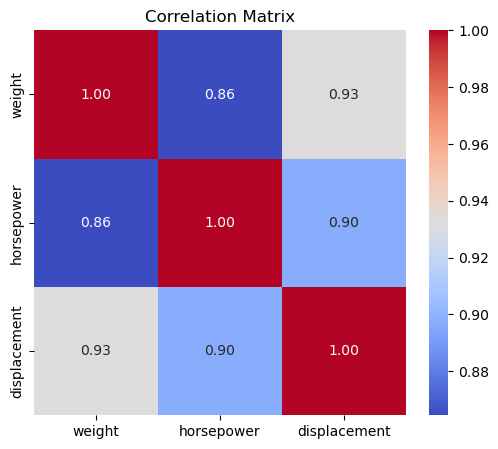

In [4]:
print('--- 1. Multicollinearity Analysis ---')

plt.figure(figsize=(6, 5))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


### 4.1) Compute VIF table

A common practical rule: `VIF > 5` suggests notable multicollinearity (and `VIF > 10` is often considered severe).


In [5]:
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print('VIF Values (VIF > 5 indicates high multicollinearity):')
print(vif_data)


VIF Values (VIF > 5 indicates high multicollinearity):
        feature        VIF
0        weight   7.957383
1    horsepower   5.287295
2  displacement  10.310539


## 5) Ridge Regression trained with SGD

Model prediction:

$$
\hat{y}_i = w^T x_i + b
$$

Ridge objective (bias is not regularized):

$$
J(w, b) = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2 + \lambda\|w\|_2^2
$$

Mini-batch gradients for batch size $m$:

$$
\nabla_w = \frac{2}{m}X^T(\hat{y}-y) + 2\lambda w,
\qquad
\nabla_b = \frac{2}{m}\sum(\hat{y}-y)
$$

Update rule:

$$
w \leftarrow w - \eta\nabla_w,
\qquad
b \leftarrow b - \eta\nabla_b
$$


In [6]:
class RidgeSGD:
    def __init__(self, learning_rate=0.01, epochs=1000, batch_size=32, lambda_reg=0.0):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.lambda_reg = lambda_reg
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        np.random.seed(42)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0
        self.loss_history = []

        for _ in range(self.epochs):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                y_pred = np.dot(X_batch, self.weights) + self.bias
                error = y_pred - y_batch
                batch_n = len(y_batch)

                dw = (2 / batch_n) * np.dot(X_batch.T, error) + (2 * self.lambda_reg * self.weights)
                db = (2 / batch_n) * np.sum(error)

                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            full_pred = np.dot(X, self.weights) + self.bias
            mse = np.mean((full_pred - y) ** 2)
            l2_penalty = self.lambda_reg * np.sum(self.weights ** 2)
            self.loss_history.append(mse + l2_penalty)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


## 6) Train/test split and experiment setup

We evaluate multiple regularization strengths:

$$
\lambda \in \{0, 0.01, 0.1, 1.0, 5.0\}
$$

Reported hyperparameters:
- Learning rate: `0.001`
- Epochs: `500`
- Mini-batch size: `32`


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

lambdas = [0, 0.01, 0.1, 1.0, 5.0]
learning_rate = 0.001
epochs = 500
batch_size = 32

results = []
weights_history = {}

print('Hyperparameters:')
print(f'  learning_rate={learning_rate}, epochs={epochs}, batch_size={batch_size}')
print(f'  lambdas={lambdas}')


Hyperparameters:
  learning_rate=0.001, epochs=500, batch_size=32
  lambdas=[0, 0.01, 0.1, 1.0, 5.0]


## 7) Train models and inspect convergence

For each $\lambda$, we record:

- Training MSE
- Testing MSE
- Loss history across epochs

Monitored loss per epoch:

$$
\text{Loss} = \text{MSE} + \lambda\|w\|_2^2,
\qquad
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2
$$


--- Training Models ---
Lambda 0: Train MSE=17.9995, Test MSE=18.3018
Lambda 0.01: Train MSE=18.0116, Test MSE=18.2602
Lambda 0.1: Train MSE=18.1644, Test MSE=17.9342
Lambda 1.0: Train MSE=21.5989, Test MSE=17.9018
Lambda 5.0: Train MSE=37.0843, Test MSE=28.7433


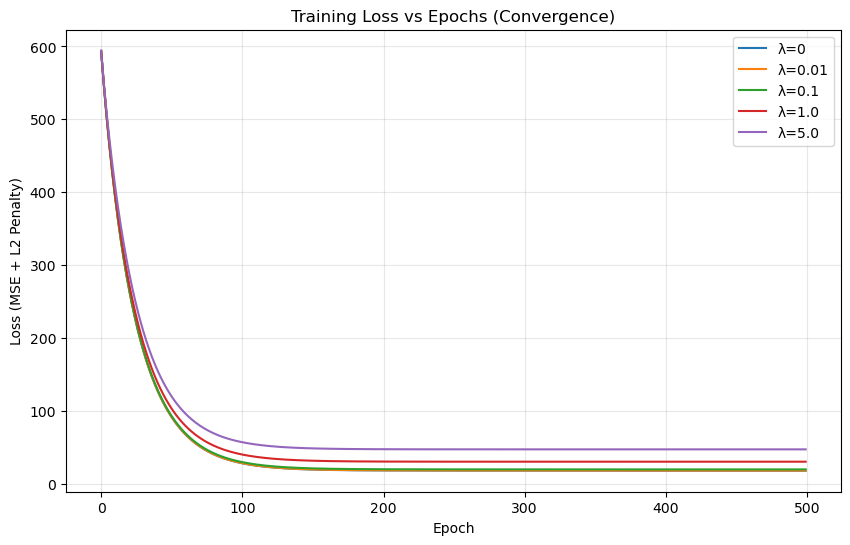

In [8]:
plt.figure(figsize=(10, 6))

print('--- Training Models ---')
for lam in lambdas:
    model = RidgeSGD(
        learning_rate=learning_rate,
        epochs=epochs,
        batch_size=batch_size,
        lambda_reg=lam,
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = np.mean((y_train_pred - y_train) ** 2)
    test_mse = np.mean((y_test_pred - y_test) ** 2)

    results.append({
        'Lambda': lam,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
    })
    weights_history[lam] = model.weights

    plt.plot(model.loss_history, label=f'λ={lam}')
    print(f'Lambda {lam}: Train MSE={train_mse:.4f}, Test MSE={test_mse:.4f}')

plt.title('Training Loss vs Epochs (Convergence)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE + L2 Penalty)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8) Compare coefficient shrinkage as $\lambda$ changes

Ridge regression should shrink coefficients toward zero as regularization increases, improving stability under multicollinearity.


--- Model Coefficients (Weights) vs Lambda ---
        weight  horsepower  displacement
0.00 -3.562128   -1.700362     -1.724985
0.01 -3.504332   -1.711304     -1.746161
0.10 -3.094780   -1.776098     -1.868672
1.00 -1.885978   -1.572887     -1.658250
5.00 -0.863024   -0.790447     -0.821426


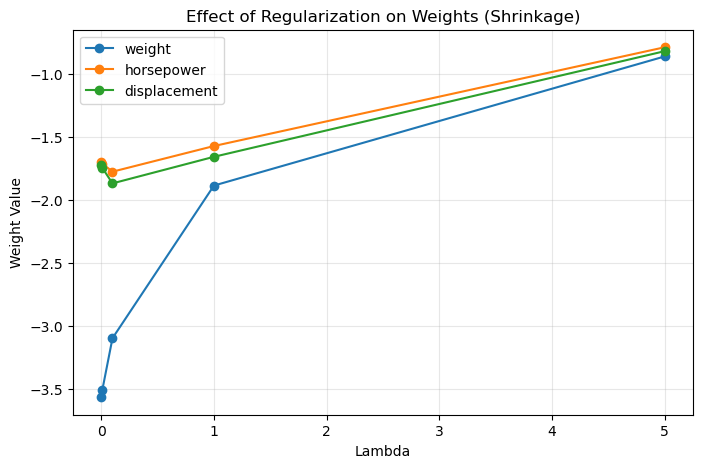

In [9]:
weights_df = pd.DataFrame(weights_history, index=X.columns).T
print('--- Model Coefficients (Weights) vs Lambda ---')
print(weights_df)

plt.figure(figsize=(8, 5))
for col in X.columns:
    plt.plot(lambdas, weights_df[col], marker='o', label=col)

plt.title('Effect of Regularization on Weights (Shrinkage)')
plt.xlabel('Lambda')
plt.ylabel('Weight Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 9) Final performance table and discussion

This cell summarizes train/test MSE for all regularization strengths and gives a short qualitative interpretation of multicollinearity and the bias-variance tradeoff.


In [10]:
results_df = pd.DataFrame(results)
print('--- Final Performance Comparison ---')
print(results_df)

print('=' * 60)
print('ANALYSIS DISCUSSION')
print('=' * 60)
print('1. Multicollinearity:')
print('   Correlation and VIF indicate overlap between predictors (e.g., weight and displacement).')
print('2. Effect of Ridge Regression:')
print('   As λ increases, coefficients shrink toward zero, making the model more stable.')
print('3. Bias-Variance Tradeoff:')
print('   - λ=0: lower bias, higher variance (possible overfitting).')
print('   - Very large λ: higher bias, lower variance (possible underfitting).')
print('   - Best λ is typically where test MSE is minimized.')


--- Final Performance Comparison ---
   Lambda  Train MSE   Test MSE
0    0.00  17.999514  18.301793
1    0.01  18.011649  18.260200
2    0.10  18.164363  17.934179
3    1.00  21.598925  17.901790
4    5.00  37.084283  28.743254
ANALYSIS DISCUSSION
1. Multicollinearity:
   Correlation and VIF indicate overlap between predictors (e.g., weight and displacement).
2. Effect of Ridge Regression:
   As λ increases, coefficients shrink toward zero, making the model more stable.
3. Bias-Variance Tradeoff:
   - λ=0: lower bias, higher variance (possible overfitting).
   - Very large λ: higher bias, lower variance (possible underfitting).
   - Best λ is typically where test MSE is minimized.
